# Score-shift diagnostic

Compare target and decoy score distributions **before vs after fine-tuning** for a chosen tool. Useful for diagnosing why FDR yields changed: target rising / decoy rising / gap widening or shrinking.

Reads `novoboard_out/<sample>/<tool>.fdr.csv` (pretrained) and `novoboard_out_finetune/<sample>/<tool>.fdr.csv` (finetuned) and shows side-by-side histograms of the score distributions per sample.

In [1]:
TOOL    = 'instanovoplus'                  # 'casanovo' | 'instanovo' | 'instanovoplus'
SAMPLES = ['Ecoli_EV_2',                   # any subset of these
           'wastewater_Sample1',
           'wastewater_Sample2']

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load(tool, sample, variant):
    root = 'novoboard_out' if variant == 'pretrained' else 'novoboard_out_finetune'
    p = Path(root) / sample / f'{tool}.fdr.csv'
    return pd.read_csv(p) if p.exists() else None

## Score-distribution histograms

Two panels per sample: pretrained on the left, finetuned on the right. Same x-range so shifts are visible at a glance.

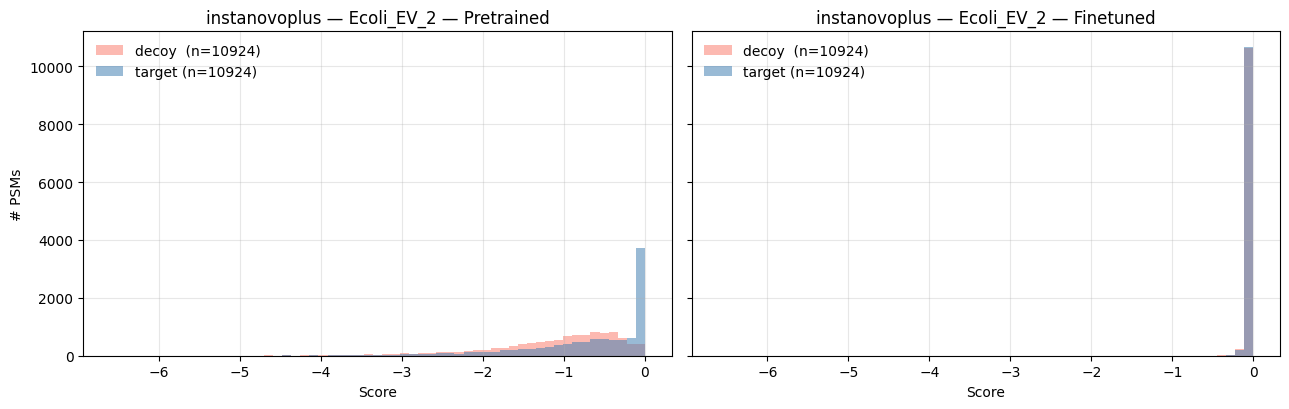

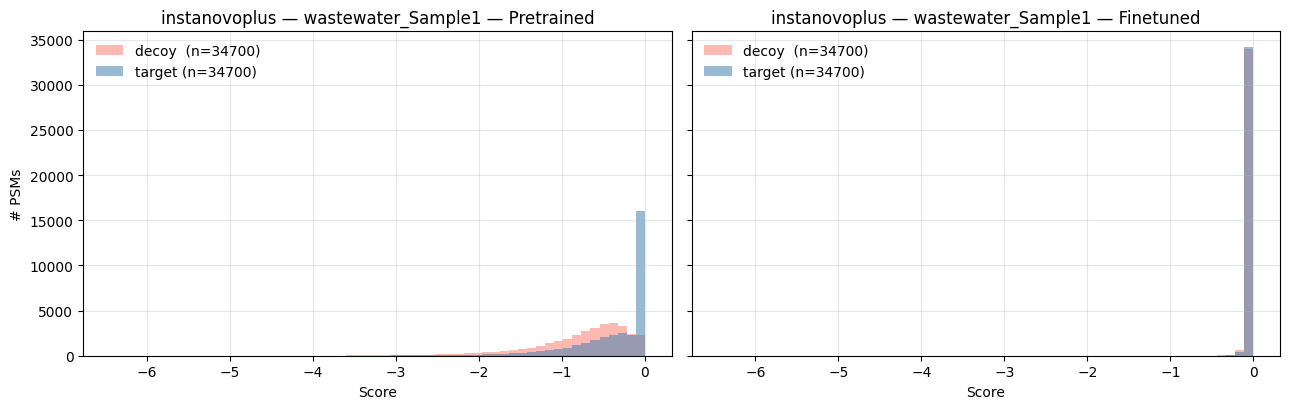

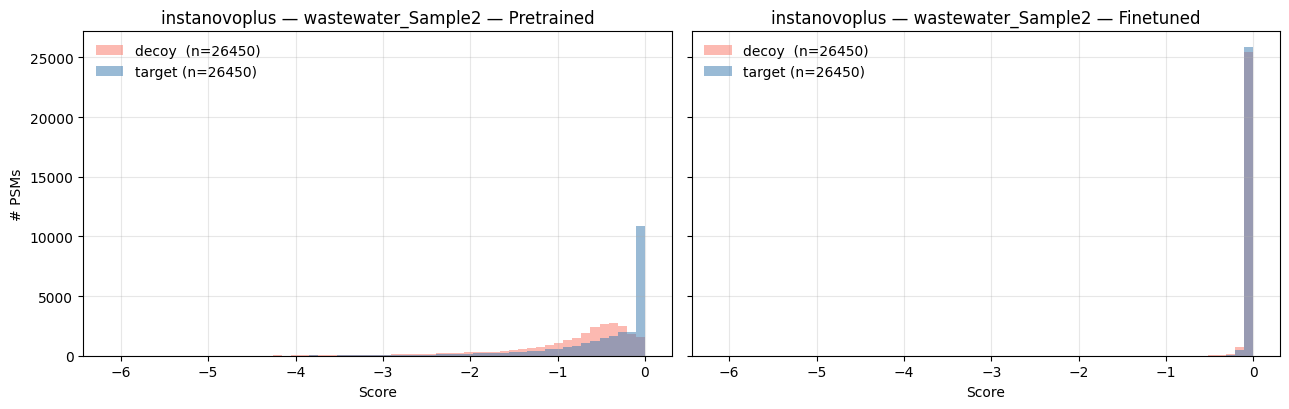

In [3]:
def plot_distributions(pre, ft, sample, tool):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True, sharey=True)
    all_scores = pd.concat([pre['Score'], ft['Score']]).dropna()
    bins = np.linspace(all_scores.min(), all_scores.max(), 60)
    for ax, label, df in zip(axes, ['Pretrained', 'Finetuned'], [pre, ft]):
        t = df.loc[df['is_target'], 'Score']
        d = df.loc[~df['is_target'], 'Score']
        ax.hist(d, bins=bins, alpha=0.55, color='salmon',    label=f'decoy  (n={len(d)})')
        ax.hist(t, bins=bins, alpha=0.55, color='steelblue', label=f'target (n={len(t)})')
        ax.set_title(f'{tool} — {sample} — {label}')
        ax.set_xlabel('Score')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper left', frameon=False)
    axes[0].set_ylabel('# PSMs')
    plt.tight_layout()
    plt.show()

for sample in SAMPLES:
    pre = load(TOOL, sample, 'pretrained')
    ft  = load(TOOL, sample, 'finetuned')
    if pre is None or ft is None:
        print(f'{sample}: missing FDR CSV (pretrained={pre is not None}, finetuned={ft is not None})')
        continue
    plot_distributions(pre, ft, sample, TOOL)